# LDH Adsorption – RR % Modeling (dataset 2026-08-04)
**Dataset:** micropollutant adsorption on LDH (Layered Double Hydroxide) materials — `Data/20260804_Data_Adsorption.xlsx`

**Goal:** predict RR % for studied LDH–pollutant systems at new operating conditions (LR, KNN, ANN, Cubist, RF, XGB, HistGB), with honest train/CV/test reporting and feature-importance analysis.

> **Scope of the claim.** The dataset's 1342 rows come from **59 source studies**: within one
> study, the material and pollutant descriptors are constant and only the operating conditions
> (pH, temperature, time, dosage, Ci) vary. These models are therefore trained and validated to
> **predict RR % for *studied* material–pollutant systems at new operating conditions**
> (within-system interpolation, row-level split with exact-duplicate rows removed).
> They are **not** validated for screening unseen materials or pollutants: a grouped split by
> source study (reported in the main notebook as a limitation analysis) shows near-zero
> cross-study R². Do not cite the interpolation metrics as evidence of screening power.

> **Methodology notes (rewrite, 2026-09):** rebuilt on the shared
> [`ldh_pipeline.py`](ldh_pipeline.py) module after a code review. Scores are reported as three
> honestly-labeled numbers (train / CV validation / hold-out test); KNN imputation, scaling and
> encoding live inside each model's Pipeline (fit on training folds only); RR % is normalized
> range-aware to [0, 100]; exact feature-duplicate rows are removed before splitting; every
> split, CV fold, and Optuna sampler is seeded; each experiment saves models + scores + config
> under its own `Model/<experiment_name>/` folder.

## 1. Setup & load

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
# On Colab: clone/mount the repo and point this at its notebooks/ folder.
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
SEED = lp.SEED
print('Data dir :', lp.DATA_DIR)
print('Model dir:', lp.MODEL_DIR)

Data dir : /home/trunght/workspace/researches/Green-X Project-BaoTien/Data
Model dir: /home/trunght/workspace/researches/Green-X Project-BaoTien/Model


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
print(f"Shape: {df.shape}")
print(f"Source studies (Id): {df['Id'].nunique()}")
print(f"RR % range: [{df['RR %'].min():.2f}, {df['RR %'].max():.2f}]")
df.head()

Shape: (1342, 32)
Source studies (Id): 59
RR % range: [0.00, 100.00]


,Id,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,68.0
1,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,12.0
2,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,20.0
3,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,36.0
4,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,45.6


## 2. Missing values

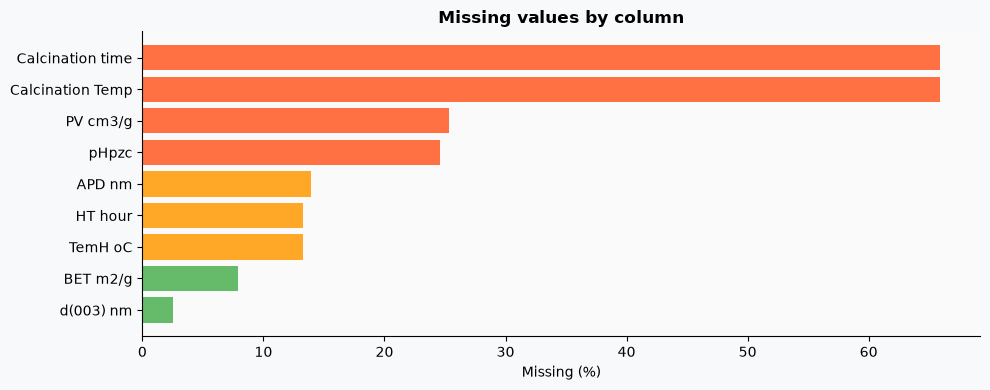

In [3]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %')
if len(miss_df):
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#FF7043' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
              for v in miss_df['Missing %']]
    ax.barh(miss_df.index, miss_df['Missing %'], color=colors)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column')
    plt.tight_layout(); plt.show()
else:
    print('No missing values')

## 3. EDA – target by pollutant and by study

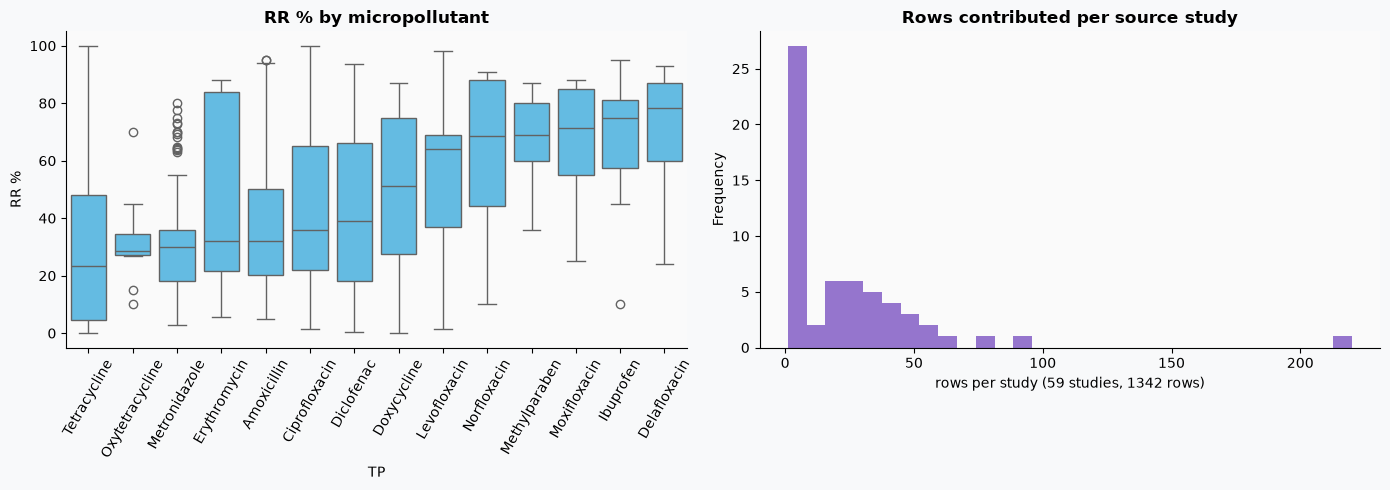

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = df.groupby('TP')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='TP', y='RR %', order=order, ax=axes[0], color='#4FC3F7')
axes[0].set_title('RR % by micropollutant')      # (old version mislabeled this as Qe mg/g)
axes[0].tick_params(axis='x', rotation=60)
df['Id'].value_counts().plot.hist(bins=30, ax=axes[1], color='#9575CD')
axes[1].set_title('Rows contributed per source study')
axes[1].set_xlabel('rows per study (59 studies, 1342 rows)')
plt.tight_layout(); plt.show()

## 4. Multicollinearity (VIF)
Computed over features only — the previous version included the targets in the regressions, which contaminated the drop decisions.

In [5]:
X_all = df.drop(columns=['Id', 'RR %'])
lp.vif_table(X_all).head(15)

/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/home/trunght/workspace/researches/Green-X Project-BaoTien/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence

,feature,VIF
0,HT hour,1.019158e+07
1,TemH oC,6.795798e+06
2,Calcination Temp,2.064460e+06
3,M(II)/(III),1.688948e+06
4,S,7.377968e+05
5,BET m2/g,7.073139e+05
6,B,6.163393e+05
7,d(003) nm,5.122396e+05
8,A,3.235245e+05
9,TSPA,1.989830e+05


## 5. Experiments
Feature sets are named configs; every run saves its models, scores, and config under
`Model/<name>/`.

- **interp_row_42** — PRIMARY: all features, row-level split (within-system interpolation),
  exact-duplicate rows removed.
- **corr_drop_interp_42** — same protocol, dropping the highly-correlated descriptor block
  (the old "Experiment 2").
- **generalization_group_42** — LIMITATION ANALYSIS: identical models under a split grouped by
  source study; measures prediction on *unseen* studies.

In [6]:
CORR_DROP = ["MW g/mol", "E", "S", "A", "B", "V", "average Pauling electronegativity",
             "average atomic weight (g/mol)", "PV cm3/g"]
MODELS = ("LR", "KNN", "ANN", "Cubist", "RF", "XGB", "HistGB")

experiments = {
    'interp_row_42': lp.ExperimentConfig(
        name='interp_row_42', split_mode='row', dedup_features=True, models=MODELS),
    'corr_drop_interp_42': lp.ExperimentConfig(
        name='corr_drop_interp_42', split_mode='row', dedup_features=True,
        drop_features=CORR_DROP, models=MODELS),
    'generalization_group_42': lp.ExperimentConfig(
        name='generalization_group_42', split_mode='group', dedup_features=True, models=MODELS),
}
runs = {}
for name, cfg in experiments.items():
    print(f"\n================ {name} ================")
    runs[name] = lp.run_experiment(cfg, df)


================ interp_row_42 ================
[interp_row_42] dropped 83 exact feature-duplicate rows
[interp_row_42] split=row  train=1007  test=252  features=30
--- Optuna tuning RF (30 trials) ---


[*] RF best params: {'n_estimators': 347, 'max_depth': 13, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---


[*] XGB best params: {'n_estimators': 495, 'learning_rate': 0.11367160721608166, 'max_depth': 13, 'min_child_weight': 7}
--- Optuna tuning HistGB (30 trials) ---


[*] HistGB best params: {'max_iter': 484, 'learning_rate': 0.08868791876058112, 'max_depth': 14, 'min_samples_leaf': 8}
--- LR ---
    Train      R2  0.4396 | MAE  16.9086
    CV (valid) R2  0.3765 | MAE  17.6526
    Test       R2  0.4390 | MAE  17.2245

--- KNN ---


[*] best params: {'n_neighbors': 1}
    Train      R2  0.9956 | MAE   0.0819
    CV (valid) R2  0.7310 | MAE   8.0307
    Test       R2  0.7583 | MAE   7.7277

--- ANN ---


...

[*] best params: {'n_committees': 9, 'neighbors': 2}


    Train      R2  0.9404 | MAE   4.4034
    CV (valid) R2 -0.0687 | MAE  22.6156
    Test       R2 -0.6405 | MAE  27.3602

--- RF ---


    Train      R2  0.9141 | MAE   5.5627
    CV (valid) R2 -0.4042 | MAE  25.5134
    Test       R2 -0.6502 | MAE  26.9565

--- XGB ---


    Train      R2  0.8193 | MAE   9.2422
    CV (valid) R2 -0.1792 | MAE  23.2005
    Test       R2 -0.3503 | MAE  24.6743

--- HistGB ---


    Train      R2  0.8728 | MAE   7.5074
    CV (valid) R2 -0.1889 | MAE  23.2896
    Test       R2 -0.5740 | MAE  26.4747



## 6. Results — primary (within-system interpolation)

In [7]:
print("=== interp_row_42 (PRIMARY) ===")
print(runs['interp_row_42']['table'].round(3))
print("\n=== corr_drop_interp_42 ===")
print(runs['corr_drop_interp_42']['table'].round(3))

=== interp_row_42 (PRIMARY) ===
        train_r2  cv_r2  test_r2  train_mae  cv_mae  test_mae  test_rmse
XGB        0.994  0.838    0.874      0.826   6.905     5.464     10.025
HistGB     0.991  0.842    0.864      1.525   6.853     5.619     10.417
KNN        0.996  0.731    0.758      0.082   8.031     7.728     13.879
Cubist     0.925  0.780    0.792      4.343   8.597     8.102     12.873
RF         0.903  0.771    0.801      5.744   9.118     8.349     12.601
ANN        0.609  0.506    0.569     13.272  15.174    14.106     18.525
LR         0.440  0.376    0.439     16.909  17.653    17.225     21.145

=== corr_drop_interp_42 ===
        train_r2  cv_r2  test_r2  train_mae  cv_mae  test_mae  test_rmse
XGB        0.986  0.837    0.863      1.866   7.026     5.825     10.454
HistGB     0.992  0.830    0.864      1.427   7.239     5.884     10.424
KNN        0.991  0.728    0.765      0.164   8.093     7.593     13.682
Cubist     0.925  0.776    0.777      4.291   8.657     8.317  

### Limitation: cross-study generalization
Same data, same models, same preprocessing — but the test set holds entire unseen studies. The gap between the two columns bounds the claim: performance reflects interpolation within studied systems, not screening of new ones.

In [8]:
cmp = pd.DataFrame({
    'test_R2 (interpolation)': runs['interp_row_42']['table']['test_r2'],
    'test_R2 (unseen studies)': runs['generalization_group_42']['table']['test_r2'],
    'test_RMSE (interpolation)': runs['interp_row_42']['table']['test_rmse'],
    'test_RMSE (unseen studies)': runs['generalization_group_42']['table']['test_rmse'],
}).round(3)
cmp.to_csv(lp.MODEL_DIR / 'claim_scope_comparison.csv')
cmp

,test_R2 (interpolation),test_R2 (unseen studies),test_RMSE (interpolation),test_RMSE (unseen studies)
ANN,0.569,-2.928,18.525,49.463
Cubist,0.792,-0.640,12.873,31.967
HistGB,0.864,-0.574,10.417,31.313
KNN,0.758,-0.118,13.879,26.391
LR,0.439,-6.382,21.145,67.813
RF,0.801,-0.650,12.601,32.061
XGB,0.874,-0.350,10.025,29.002


## 7. Best model – performance visualization

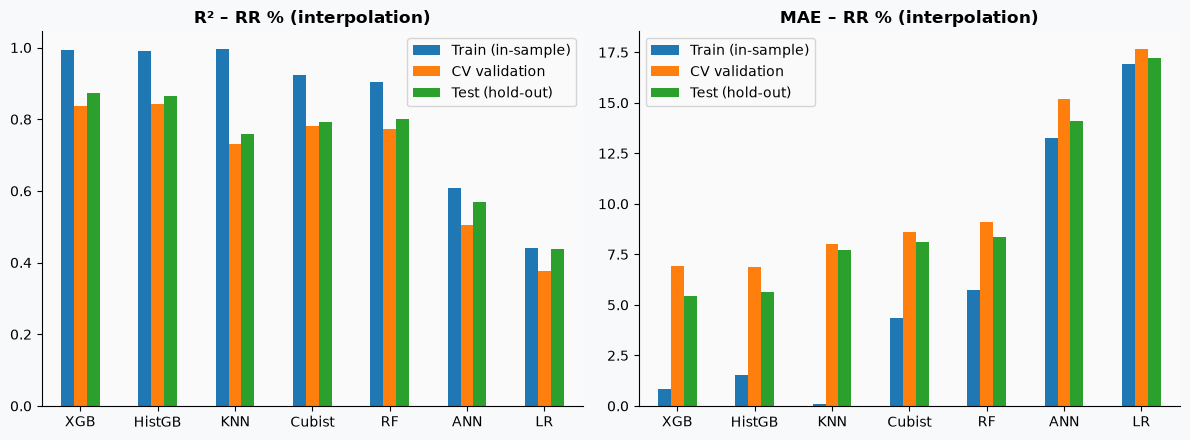

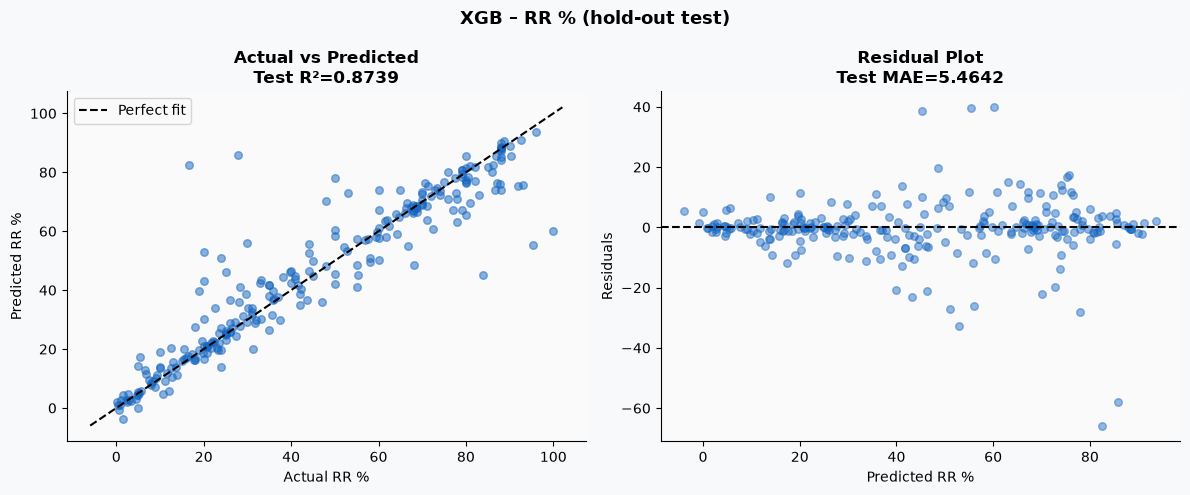

In [9]:
run = runs['interp_row_42']
lp.plot_model_comparison(run['table'], 'RR % (interpolation)',
                         out_path=run['out_dir'] / 'model_results.png')
best_name = run['table'].index[0]  # lowest test MAE
lp.plot_parity(run['results'][best_name], 'RR %',
               out_path=run['out_dir'] / 'best_model_parity.png')

## 8. Feature importance
Permutation importance and SHAP are computed with the already-fitted models on the hold-out test set.

In [10]:
ranks = lp.permutation_ranks(run['results'], run['X_test'], run['y_test'])
ranks.to_csv(run['out_dir'] / 'permutation_importance.csv')  # keeps feature index
ranks.sort_values('HistGB')

,LR,KNN,ANN,Cubist,RF,XGB,HistGB
AD g/L,27,1,29,1,1,1,1
Time h,19,3,1,2,2,2,2
Ci mg/L,22,4,14,3,3,4,3
pH,25,2,4,5,7,5,4
pHpzc,26,7,19,9,4,7,5
BET m2/g,24,5,2,7,6,6,6
Log Kow,11,9,16,18,5,3,7
average Pauling electronegativity,15,13,7,15,9,9,8
PV cm3/g,10,16,12,4,8,10,9
d(003) nm,8,6,8,8,12,8,10


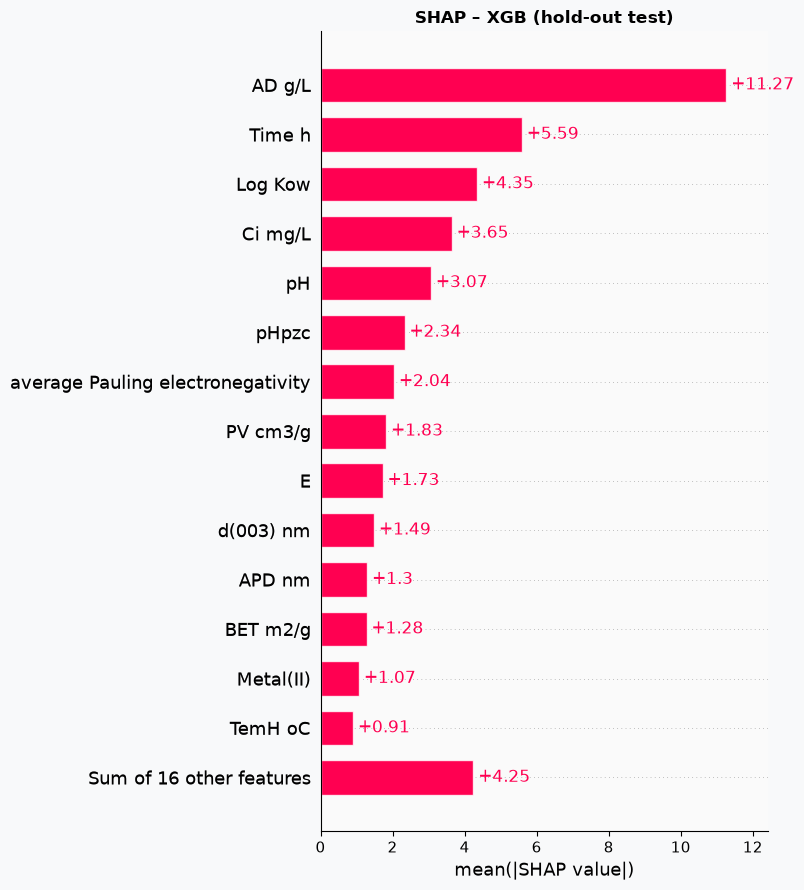

In [11]:
import shap
best_tree = run['table'].loc[run['table'].index.isin(['HistGB', 'XGB', 'RF'])].index[0]
sv, feat_names = lp.shap_summary(run['results'][best_tree], run['X_test'])
sv.feature_names = feat_names
shap.plots.bar(sv, max_display=15, show=False)
plt.title(f'SHAP – {best_tree} (hold-out test)')
plt.tight_layout()
plt.savefig(run['out_dir'] / 'shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Conclusions
- **Claim:** for material–pollutant systems present in the training data, the models predict RR % at new operating conditions with the accuracy shown in the primary table (tree ensembles lead).
- **Limitation (stated, quantified):** cross-study R² is near zero — these models do not yet transfer to unseen materials/pollutants; `Model/claim_scope_comparison.csv` documents the gap.
- Model files, scores, and configs for every experiment live in `Model/<name>/`.